# Credit Card Fraud Detection

## Business Problem

Financial institutions need to identify potentially fraudulent transactions while minimizing the number of legitimate transactions incorrectly flagged for investigation.

This project analyzes credit card transactions to:

1. Understand the characteristics of fraudulent transactions.
2. Identify transaction-level patterns associated with fraud.
3. Investigate whether transaction timing and transaction value are associated with higher fraud risk.
4. Use SQL to answer targeted business questions.
5. Apply Isolation Forest to identify anomalous transactions.
6. Evaluate how well detected anomalies align with known fraudulent transactions.
7. Translate analytical findings into practical fraud-monitoring recommendations.

## Analytical Approach

The analysis combines:

- **Python** for data preparation, exploratory analysis and anomaly detection.
- **SQL / SQLite** for targeted transaction analysis.
- **Statistical analysis** to compare fraudulent and legitimate transactions.
- **Isolation Forest** for unsupervised anomaly detection.

In [1]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

## 1. Data Loading

The dataset contains 284,807 credit card transactions made over approximately two days.

The available variables include:

- `Time`: seconds elapsed since the first transaction.
- `V1`–`V28`: anonymized transaction features.
- `Amount`: transaction amount.
- `Class`: target variable where 0 represents legitimate transactions and 1 represents fraud.

In [3]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (284807, 31)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 2. Data Quality Assessment

Before analyzing fraud patterns, the dataset is checked for:

- Missing values
- Duplicate observations
- Data types
- Class distribution

This ensures that the subsequent analysis is based on a reliable analytical dataset.

In [6]:
missing_values = df.isnull().sum()
print(f"Missing values per column:\n{missing_values}")

Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [8]:
duplicate_count=df.duplicated().sum()
print(f"Duplicate rows:{duplicate_count}")

Duplicate rows:1081


In [16]:
df = df.drop_duplicates().copy()

print(f"Dataset shape after removing duplicates: {df.shape}")

Dataset shape after removing duplicates: (283726, 31)


In [17]:
print(f"Remaining duplicate rows: {df.duplicated().sum()}")

Remaining duplicate rows: 0


### Duplicate Records

The dataset was checked for exact duplicate observations. Duplicate rows were identified where all transaction fields, including the fraud label, were identical.

These exact duplicates were removed to prevent repeated observations from disproportionately influencing transaction counts, fraud-rate calculations and anomaly detection.

After removal, the dataset was rechecked to confirm that no exact duplicate rows remained.

In [24]:
print(f"Duplicate rows found: {duplicate_count}")
print(f"Dataset shape after removing duplicates: {df.shape}")
print(f"Remaining duplicate rows: {df.duplicated().sum()}")

Duplicate rows found: 1081
Dataset shape after removing duplicates: (283726, 31)
Remaining duplicate rows: 0


In [18]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [20]:
class_counts = df["Class"].value_counts()

class_counts

Class
0    283253
1       473
Name: count, dtype: int64

In [21]:
class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

class_percentages

Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64

In [22]:
fraud_rate = df["Class"].mean()

print(f"Fraud rate: {fraud_rate:.4%}")

Fraud rate: 0.1667%


In [25]:
fraud_summary = pd.DataFrame({
    "Transaction_Count": class_counts,
    "Percentage": class_percentages
})

fraud_summary.index = ["Legitimate", "Fraud"]

fraud_summary

,Transaction_Count,Percentage
Legitimate,283253,99.8333
Fraud,473,0.1667


### Class Distribution

The dataset is highly imbalanced, with Fraudulent transactions representing only 0.1667% of the cleaned dataset, while 99.8333% are legitimate transactions.

This imbalance is important for fraud detection because a model can achieve very high accuracy simply by classifying most transactions as legitimate.

Therefore, model performance will be evaluated primarily using:

- Precision
- Recall
- F1-score

rather than accuracy alone.

In [26]:
SECONDS_PER_DAY = 24 * 60 * 60

df["Time_of_Day_Seconds"] = df["Time"] % SECONDS_PER_DAY

df["Hour"] = (
    df["Time_of_Day_Seconds"] // 3600
).astype(int)

df[["Time", "Time_of_Day_Seconds", "Hour"]].head()

,Time,Time_of_Day_Seconds,Hour
0,0.0,0.0,0
1,0.0,0.0,0
2,1.0,1.0,0
3,1.0,1.0,0
4,2.0,2.0,0


In [27]:
df["Is_Early_Morning"] = (
    df["Hour"].between(0, 5)
).astype(int)

df[["Hour", "Is_Early_Morning"]].head()

,Hour,Is_Early_Morning
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [28]:
df["Log_Amount"] = np.log1p(df["Amount"])

df[["Amount", "Log_Amount"]].head()

,Amount,Log_Amount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


## 3. Feature Engineering

Three transaction-level features are created:

- **Time_of_Day_Seconds:** converts the elapsed transaction time into its position within a 24-hour cycle.
- **Hour:** extracts the approximate hour of the day.
- **Is_Early_Morning:** identifies transactions occurring between 00:00 and 05:59.
- **Log_Amount:** log-transforms transaction amount to reduce the influence of extreme values.

These features allow the analysis to investigate transaction timing and transaction value more directly.

In [29]:
df[[
    "Time",
    "Time_of_Day_Seconds",
    "Hour",
    "Is_Early_Morning",
    "Amount",
    "Log_Amount",
    "Class"
]].head(10)

,Time,Time_of_Day_Seconds,Hour,Is_Early_Morning,Amount,Log_Amount,Class
0,0.0,0.0,0,1,149.62,5.014760,0
1,0.0,0.0,0,1,2.69,1.305626,0
2,1.0,1.0,0,1,378.66,5.939276,0
3,1.0,1.0,0,1,123.50,4.824306,0
4,2.0,2.0,0,1,69.99,4.262539,0
5,2.0,2.0,0,1,3.67,1.541159,0
6,4.0,4.0,0,1,4.99,1.790091,0
7,7.0,7.0,0,1,40.80,3.732896,0
8,7.0,7.0,0,1,93.20,4.545420,0
9,9.0,9.0,0,1,3.68,1.543298,0


In [30]:
df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
Class,,,,
0,283253,88.413575,22.00,25691.16
1,473,123.871860,9.82,2125.87


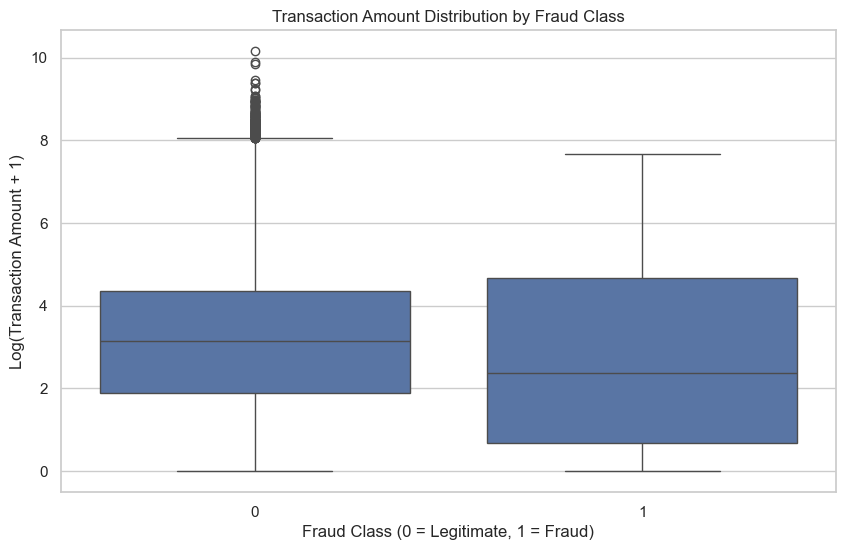

In [31]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Log_Amount"
)

plt.title("Transaction Amount Distribution by Fraud Class")
plt.xlabel("Fraud Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Log(Transaction Amount + 1)")

plt.show()

In [32]:
amount_99th_percentile = df["Amount"].quantile(0.99)

print(
    f"99th percentile transaction amount: "
    f"${amount_99th_percentile:,.2f}"
)

99th percentile transaction amount: $1,018.97


In [34]:
df["High_Value"] = (
    df["Amount"] >= amount_99th_percentile
).astype(int)

In [35]:
fraud_rate_by_value = (
    df.groupby("High_Value")["Class"]
    .agg(["count", "sum", "mean"])
)

fraud_rate_by_value

,count,sum,mean
High_Value,,,
0,280888,464,0.001652
1,2838,9,0.003171


In [36]:
fraud_rate_by_value.columns = [
    "Transactions",
    "Fraud_Count",
    "Fraud_Rate"
]

fraud_rate_by_value["Fraud_Rate"] *= 100

fraud_rate_by_value

,Transactions,Fraud_Count,Fraud_Rate
High_Value,,,
0,280888,464,0.165190
1,2838,9,0.317125


In [37]:
fraud_rate_by_hour = (
    df.groupby("Hour")["Class"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

fraud_rate_by_hour["Fraud_Rate"] *= 100

fraud_rate_by_hour

,Transactions,Fraud_Count,Fraud_Rate
Hour,,,
0,7647,6,0.078462
1,4208,10,0.237643
2,3308,48,1.451028
3,3487,17,0.487525
4,2204,23,1.043557
5,2988,11,0.368139
6,4082,9,0.220480
7,7233,23,0.317987
8,10232,9,0.087959


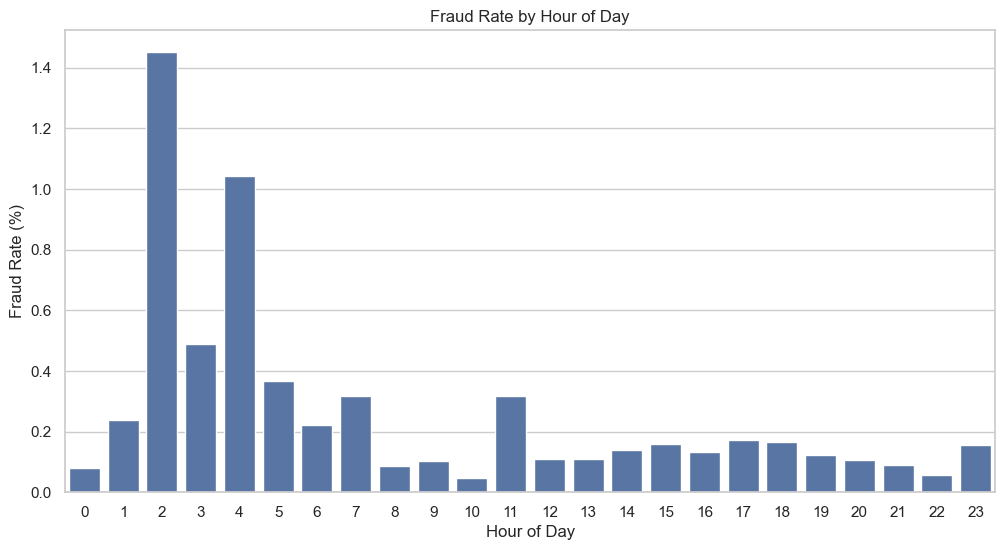

In [38]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=fraud_rate_by_hour.reset_index(),
    x="Hour",
    y="Fraud_Rate"
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [39]:
early_morning_analysis = (
    df.groupby("Is_Early_Morning")["Class"]
    .agg(
        Transactions="count",
        Fraud_Count="sum",
        Fraud_Rate="mean"
    )
)

early_morning_analysis["Fraud_Rate"] *= 100

early_morning_analysis

,Transactions,Fraud_Count,Fraud_Rate
Is_Early_Morning,,,
0,259884,358,0.137754
1,23842,115,0.482342


In [40]:
early_rate = early_morning_analysis.loc[1, "Fraud_Rate"]
other_rate = early_morning_analysis.loc[0, "Fraud_Rate"]

relative_risk = early_rate / other_rate

print(f"Early-morning fraud rate: {early_rate:.4f}%")
print(f"Other-hours fraud rate: {other_rate:.4f}%")
print(f"Relative risk: {relative_risk:.2f}x")

Early-morning fraud rate: 0.4823%
Other-hours fraud rate: 0.1378%
Relative risk: 3.50x


### Early-Morning Fraud Pattern

Transactions occurring between 00:00 and 05:59 show a higher observed fraud rate than transactions occurring during other hours.

- Early-morning transactions: **0.4823% fraud rate**
- Other transactions: **0.1378% fraud rate**

The early-morning fraud rate is approximately **3.5 times higher** than the rate observed during other hours.

This suggests that transaction timing may be a useful risk indicator for fraud monitoring. However, time of day should not be treated as a standalone fraud rule because most early-morning transactions are still legitimate.

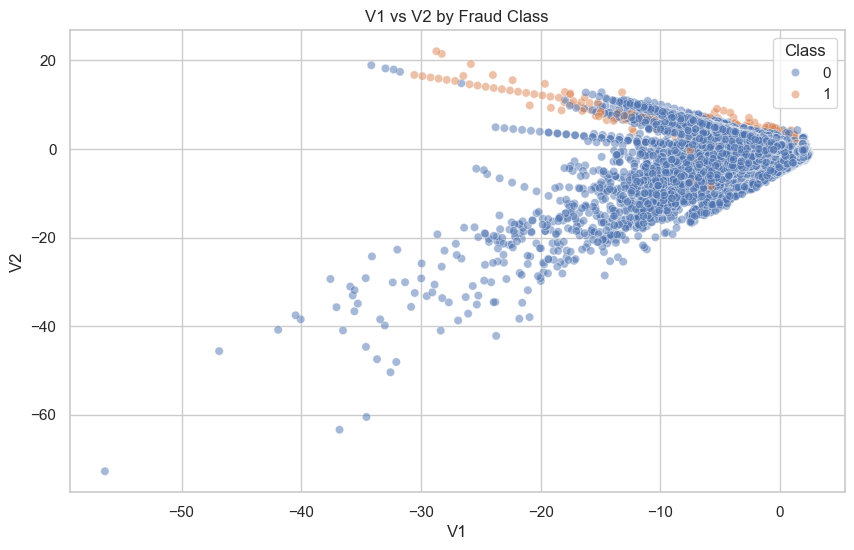

In [41]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="V1",
    y="V2",
    hue="Class",
    alpha=0.5
)

plt.title("V1 vs V2 by Fraud Class")
plt.xlabel("V1")
plt.ylabel("V2")

plt.show()